1. Установка библиотек

In [17]:
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [1]:
%pip install numpy==1.26.4
%pip install "opencv-contrib-python<4.12" matplotlib python-pptx

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/46.2 MB ? eta -:--:--
    --------------------------------------- 1.0/46.2 MB 4.2 MB/s eta 0:00:11
   - -------------------------------------- 1.8/46.2 MB 4.6 MB/s eta 0:00:10
   -- ------------------------------------- 3.1/46.2 MB 4.6 MB/s eta 0:00:10
   --- ------------------------------------ 3.9/46.2 MB 4.6 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/46.2 MB 4.6 MB/s eta 0:00:09
   ---- ----------------------------------- 5.5/46.2 MB 4.4 MB/s eta 0:00:10
   ----- ---------------------------------- 6.0/46.2 MB 4.2 MB/s eta 0:00:10
   ----- ---------------------------------- 6.6/46.2 MB 3.9 MB/s eta 0:00:11
   ------ --------------------------------- 7.1/46.2 MB 3.7 MB/s eta 0:00:11
   ------ --------------------------------- 7.6/46.2 MB 3.6 MB/s eta 0:00:11
   ------- -------------

2. Импорт библиотек

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pptx import Presentation

3. Загрузка изображения с выключенным экраном

(-0.5, 1279.5, 959.5, -0.5)

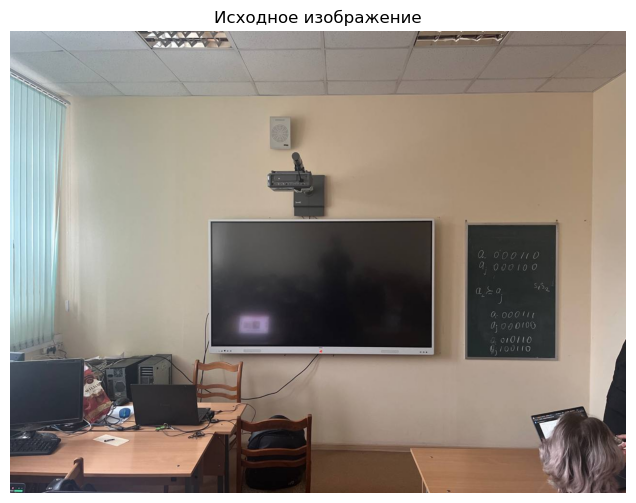

In [44]:
image_path = "D:/CVLabs/Lab2/tv.jpg"   # изображение с телевизором/экраном
img = cv2.imread(image_path)
if img is None:
    print("Error: Image not found or path is incorrect")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.title("Исходное изображение")
plt.imshow(img_rgb)
plt.axis("off")

4. Загрузка первого слайда из презентации

Exporting slide 1 to D:\CVLabs\Lab2\Slides\slide1.png


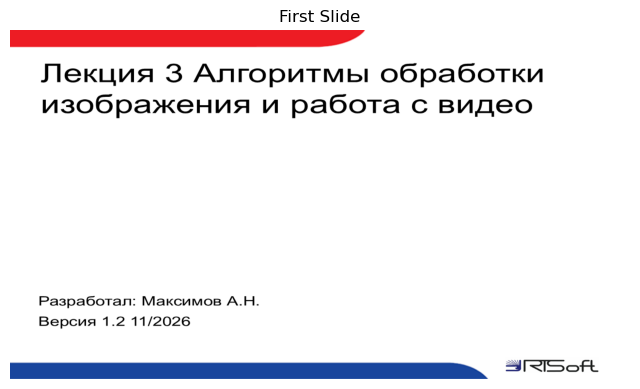

In [46]:
import win32com.client

# Use backslashes and raw string
ppt_path = "D:/CVLabs/Lab2/Lecture3_video_p1.pptx"
output_dir = "D:/CVLabs/Lab2/Slides"
os.makedirs(output_dir, exist_ok=True)
output_path = r"D:\CVLabs\Lab2\Slides\slide1.png"

# Delete old file if exists
if os.path.exists(output_path):
    os.remove(output_path)

# Launch PowerPoint
ppt_app = win32com.client.Dispatch("PowerPoint.Application")
ppt_app.Visible = True  # Must be True

# Open presentation
presentation = ppt_app.Presentations.Open(ppt_path)

if presentation.Slides.Count >= 1:
    slide = presentation.Slides[0]  # 1-based index
    print(f"Exporting slide 1 to {output_path}")
    slide.Export(output_path, "PNG", 1280, 720)
else:
    print("No slides found!")

presentation.Close()
ppt_app.Quit()

# Display in Jupyter
img1 = cv2.imread(output_path)
img_rgb1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb1)
plt.axis("off")
plt.title("First Slide")
plt.show()

5. Поиск границ (Canny)

(-0.5, 1279.5, 959.5, -0.5)

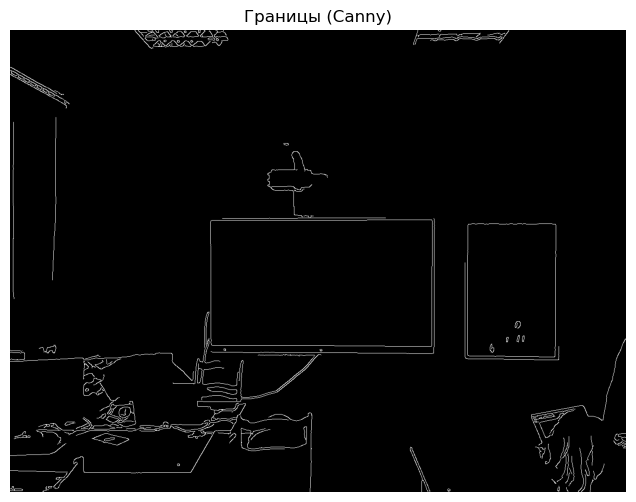

In [47]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 1.5)

edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(8,6))
plt.title("Границы (Canny)")
plt.imshow(edges, cmap="gray")
plt.axis("off")

6. Поиск контуров экрана

(-0.5, 1279.5, 959.5, -0.5)

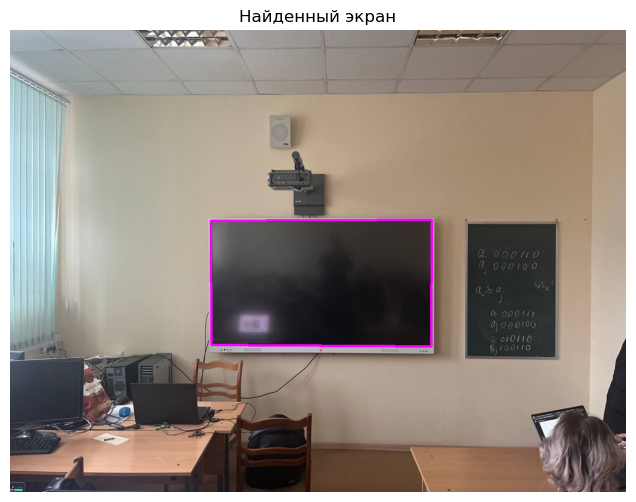

In [49]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

screen_contour = None
max_area = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > max_area:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            screen_contour = approx
            max_area = area

img_contours = img.copy()
cv2.drawContours(img_contours, [screen_contour], -1, (255,0,255), 3)

plt.figure(figsize=(8,6))
plt.title("Найденный экран")
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.axis("off")

7. Подготовка точек для гомографии

In [82]:
# Load the exported slide image (with all text and formatting)
slide_path = "D:/CVLabs/Lab2/Slides/slide1.png"
slide_img = cv2.imread(slide_path)

# Flip horizontally (mirror left-right)
slide_img = cv2.flip(slide_img, 1)  # 1 = horizontal flip

# Get bounding box of the screen
pts_dst = screen_contour.reshape(4, 2).astype(np.float32)
x, y, w_screen, h_screen = cv2.boundingRect(pts_dst.astype(int))

# Resize slide image to match the screen bounding box
slide_resized = cv2.resize(slide_img, (w_screen, h_screen))

# New source points (corners of resized slide)
pts_src = np.array([
    [0, 0],
    [w_screen-1, 0],
    [w_screen-1, h_screen-1],
    [0, h_screen-1]
], dtype=np.float32)

# Destination points are the same as before
pts_dst_float = pts_dst.astype(np.float32)

8. Вычисление гомографии

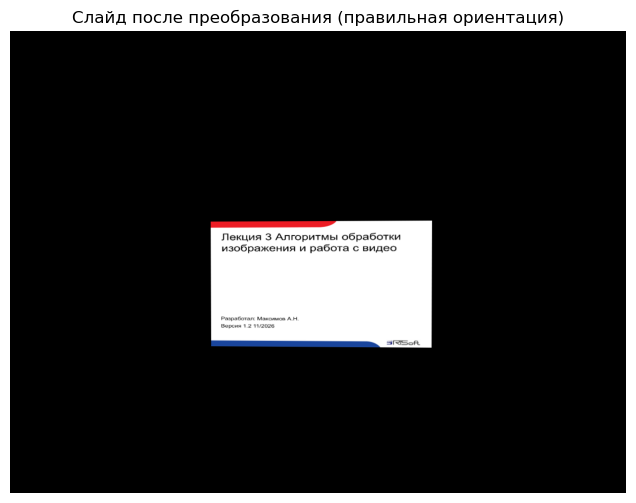

In [83]:
# Compute homography
H, _ = cv2.findHomography(pts_src, pts_dst_float)
warped_slide = cv2.warpPerspective(slide_resized, H, (img.shape[1], img.shape[0]))

# Show result
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(warped_slide, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Слайд после преобразования (правильная ориентация)")
plt.show()

9. Наложение слайда из презентации на экран

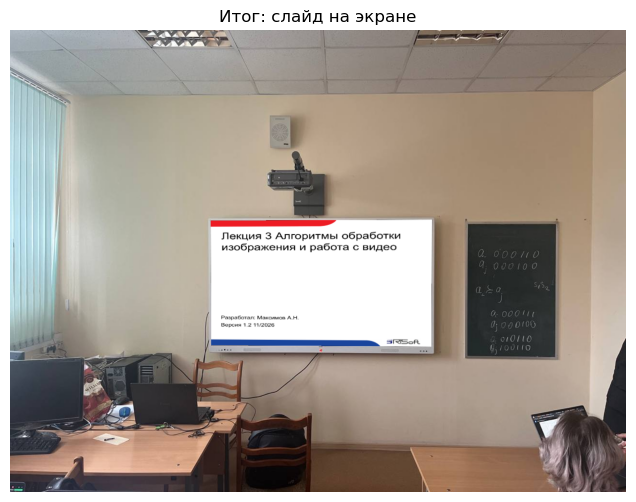

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Make sure warped_slide and img1 have the same output size
# Assuming warped_slide is already warped to match img

# Create a single-channel mask, same size as warped_slide
mask = np.zeros((warped_slide.shape[0], warped_slide.shape[1]), dtype=np.uint8)
cv2.fillConvexPoly(mask, pts_dst.astype(int), 255)  # white polygon

# Invert mask
mask_inv = cv2.bitwise_not(mask)

# Resize mask to match img size if needed
if warped_slide.shape[:2] != img.shape[:2]:
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_inv = cv2.resize(mask_inv, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    warped_slide = cv2.resize(warped_slide, (img.shape[1], img.shape[0]))

# Extract background from original image
img_bg = cv2.bitwise_and(img, img, mask=mask_inv)

# Extract warped slide foreground
slide_fg = cv2.bitwise_and(warped_slide, warped_slide, mask=mask)

# Combine
result = cv2.add(img_bg, slide_fg)

# Show
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Итог: слайд на экране")
plt.show()